# Anomaly detection

Jeet Purohit 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import eli5
from lime.lime_tabular import LimeTabularExplainer

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
)

In [ ]:
df = pd.read_csv("loan_data.csv")
print(f"Shape: {df.shape}")
df.head()

In [ ]:
print("Data types:")
print(df.dtypes)

In [ ]:
# Data distribution analysis
# GÖR DENNA BÄTTRE ELLER GRAFISKT
# KANSKE FLYTTA TILL SLUTET AV PREPROCCESSING STEGET
features = [
    'person_age', 'person_gender', 'person_education', 'person_income',
    'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
    'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
    'credit_score', 'previous_loan_defaults_on_file', 'loan_status'
]

categorical = [
    'person_gender', 'person_education', 'person_home_ownership',
    'loan_intent', 'previous_loan_defaults_on_file'
]
numerical = [f for f in features if f not in categorical]

for col in features:
    print(f"\n {col}")
    if col in numerical:
        print(f"  Min: {df[col].min()} | Max: {df[col].max()} | Mean: {df[col].mean():.2f} | Std: {df[col].std():.2f}")
    else:
        counts = df[col].value_counts()
        total = counts.sum()
        for val, cnt in counts.items():
            pct = cnt / total * 100
            print(f"  {val}: {cnt} ({pct:.1f}%)")

# Data Preproccessing

* Remove unnessesary features: Person_Gender
* The the means for each gender are not far apart, but we think that it is a possibility that the model will learn some bias from the data we have.

In [ ]:
mean_income_by_gender = df.groupby("person_gender")["person_income"].mean()
for gender, mean_income in mean_income_by_gender.items():
    print(f"{gender}: Mean income = {mean_income:.2f}")

* We want to change some of the categorical columns to Numerical values
* We also remove unnessesary features like "person_gender" beacuase this might not be needed

In [ ]:
df = df.drop(columns=["person_gender"])

In [ ]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
print(f"Categorical columns: {cat_cols}\n")

In [ ]:
label_encoders = {}
df_numerical = df.copy()

for col in cat_cols:
    le = LabelEncoder()
    df_numerical[col] = le.fit_transform(df_numerical[col])
    label_encoders[col] = le
    # print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nEncoded shape: {df_numerical.shape}")
df_numerical.head()

In [ ]:
for col in cat_cols:
    le = LabelEncoder()
    le.fit(df[col])
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col} mapping:")
    for k, v in mapping.items():
        print(f"  {k}: {v}")
    print()

# Missing values/incomplete samples

In [ ]:
nulls = df_numerical.isnull().sum()
total_null = nulls.sum()
print("number of null", total_null)

# Outliers
* we se that there are only 7 people over 100 taking loans, we remove this beacause------------------- below cells we first caount all the outliers and then remove them
* 24 åpeople over income person
* 12 people over 50 year sof eperiance, you usially take pension at 65 years old
* we converted float to int in cb_person_cred_hist_length because we saw that there were no float values. 

In [ ]:
# Count samples where person_age > 100

person_age_100 = (df_numerical['person_age'] >= 100).sum()
print(f"Number of samples with person_age >= 100: {person_age_100}")

In [ ]:
person_income_1M = (df_numerical['person_income'] > 1000000).sum()
print(f"Number of samples with person_income > 1M: {person_income_1M}")

In [ ]:
person_emp_exp_over_ = (df_numerical['person_emp_exp'] > 50).sum()
print(f"Number of samples with person_emp_exp > 50: {person_emp_exp_over_}")

In [ ]:
# Check for float columns and show unique values for cb_person_cred_hist_length
# float_cols = df.select_dtypes(include='float')
# print("Float columns:", float_cols.columns.tolist())

# if 'cb_person_cred_hist_length' in df.columns:
#     print("Unique values in cb_person_cred_hist_length:")
print(sorted(df_numerical['cb_person_cred_hist_length'].unique()))

In [ ]:
# Convert all values in cb_person_cred_hist_length to integers
print(df_numerical['cb_person_cred_hist_length'].head())
df_numerical['cb_person_cred_hist_length'] = df_numerical['cb_person_cred_hist_length'].astype(int)

print(df_numerical['cb_person_cred_hist_length'].head())

In [ ]:
# print(f"Before cleaning: {df.shape[0]} rows")

# remove unrealistic ages (e.g. 100+)
df_numerical = df_numerical[df_numerical["person_age"] <= 100]

# remove extreme employment experience outliers
df_numerical = df_numerical[df_numerical["person_emp_exp"] <= 60]

print(f"After cleaning: {df.shape[0]} rows")
print(f"Removed {45000 - df.shape[0]} outlier rows")

# Data preprocessing 
* splitting the data test aand shit

In [ ]:
X = df_numerical.drop(columns=["loan_status"])
y = df_numerical["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42, class_weight="balanced")
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = ["f1", "precision", "recall"]
cv_results = cross_validate(dt_model, X_train, y_train, cv=skf, scoring=scoring,
                            return_train_score=False)

print("Stratified 5-Fold CV Results:\n")
for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric:>10s}:  mean={scores.mean():.4f}  std={scores.std():.4f}")

# test on unseen data
- this thest is made so we can se if our model perofms similar to above, not similar = overfitting or problem in data splitting

In [ ]:
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

test_f1   = f1_score(y_test, y_pred)
test_prec = precision_score(y_test, y_pred)
test_rec  = recall_score(y_test, y_pred)

print(f"{test_f1}")
print(test_prec)
print(test_rec)


# confusion metric
snacka om specificity

In [ ]:
# specificity = TN / (TN + FP)
cm_baseline = confusion_matrix(y_test, y_pred)
test_spec = cm_baseline[0, 0] / (cm_baseline[0, 0] + cm_baseline[0, 1])

print(f"  Specificity: {test_spec:.4f}")
print()

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Rejected", "Approved"], cmap="Blues", ax=ax)
ax.set_title("Confusion Matrix - Baseline")
plt.tight_layout()
plt.show()

# print tree


In [ ]:
print(f"Total rows: {df_numerical.shape[0]}")

# återkom om nedan och see om ni kan läsa av

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X_train.columns, class_names=['Not Approved', 'Approved'], filled=True, max_depth=3)
plt.show()

# feature importance

Tree depth: 32
Number of leaves: 2807

previous_loan_defaults_on_file    0.4851
loan_int_rate                     0.1300
person_income                     0.1071
loan_percent_income               0.0775
credit_score                      0.0518
loan_amnt                         0.0294
loan_intent                       0.0286
person_age                        0.0219
person_home_ownership             0.0196
cb_person_cred_hist_length        0.0194
person_emp_exp                    0.0173
person_education                  0.0124


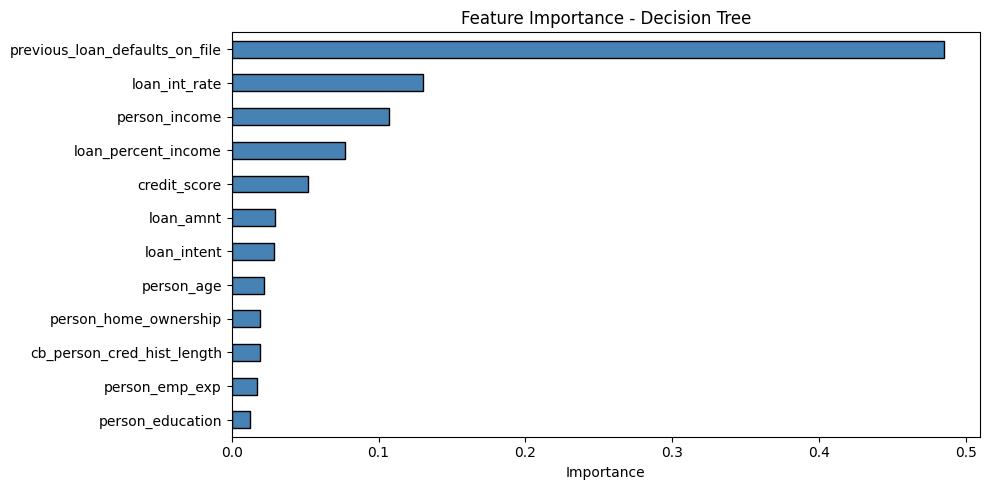

In [52]:
importances = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False)

print(f"Tree depth: {dt_model.get_depth()}")
print(f"Number of leaves: {dt_model.get_n_leaves()}\n")
print(importances.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
importances.plot.barh(ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Feature Importance - Decision Tree")
ax.set_xlabel("Importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

innan fortsättning, kanske måste träna full data set.